In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load sales data
sales_data = pd.read_csv("superstore_sales.csv")

print("Dataset shape:", sales_data.shape)
print("\nColumns:")
print(sales_data.columns.tolist())

display(sales_data.head())

Dataset shape: (9800, 18)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
# Check the data types of important columns

print("Order Date data type:")
print(sales_data["Order Date"].dtype)

print("\nSales data type:")
print(sales_data["Sales"].dtype)

Order Date data type:
object

Sales data type:
float64


In [3]:
# Convert Order Date from text to datetime

sales_data["Order Date"] = pd.to_datetime(
    sales_data["Order Date"],
    dayfirst=True
)

print("Order Date data type after conversion:")
print(sales_data["Order Date"].dtype)

display(sales_data[["Order Date", "Sales"]].head())

Order Date data type after conversion:
datetime64[ns]


,Order Date,Sales
0,2017-11-08,261.9600
1,2017-11-08,731.9400
2,2017-06-12,14.6200
3,2016-10-11,957.5775
4,2016-10-11,22.3680


In [4]:
# Calculate total revenue for each day

daily_revenue = (
    sales_data
    .groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

# Rename columns
daily_revenue.columns = ["Date", "Revenue"]

# Sort chronologically
daily_revenue = daily_revenue.sort_values("Date")

print("Daily revenue records:", len(daily_revenue))

display(daily_revenue.head(10))

Daily revenue records: 1230


,Date,Revenue
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158
5,2015-01-09,40.544
6,2015-01-10,54.830
7,2015-01-11,9.940
8,2015-01-13,3553.795
9,2015-01-14,61.960


In [5]:
# Create a continuous daily date range

full_dates = pd.date_range(
    start=daily_revenue["Date"].min(),
    end=daily_revenue["Date"].max(),
    freq="D"
)

# Reindex the revenue data to include every day
daily_revenue = (
    daily_revenue
    .set_index("Date")
    .reindex(full_dates, fill_value=0)
)

# Give the index a name
daily_revenue.index.name = "Date"

# Check the result
print("Date range:")
print(daily_revenue.index.min(), "to", daily_revenue.index.max())

print("\nTotal daily records:", len(daily_revenue))

display(daily_revenue.head(10))

Date range:
2015-01-03 00:00:00 to 2018-12-30 00:00:00

Total daily records: 1458


,Revenue
Date,
2015-01-03,16.448
2015-01-04,288.060
2015-01-05,19.536
2015-01-06,4407.100
2015-01-07,87.158
2015-01-08,0.000
2015-01-09,40.544
2015-01-10,54.830
2015-01-11,9.940


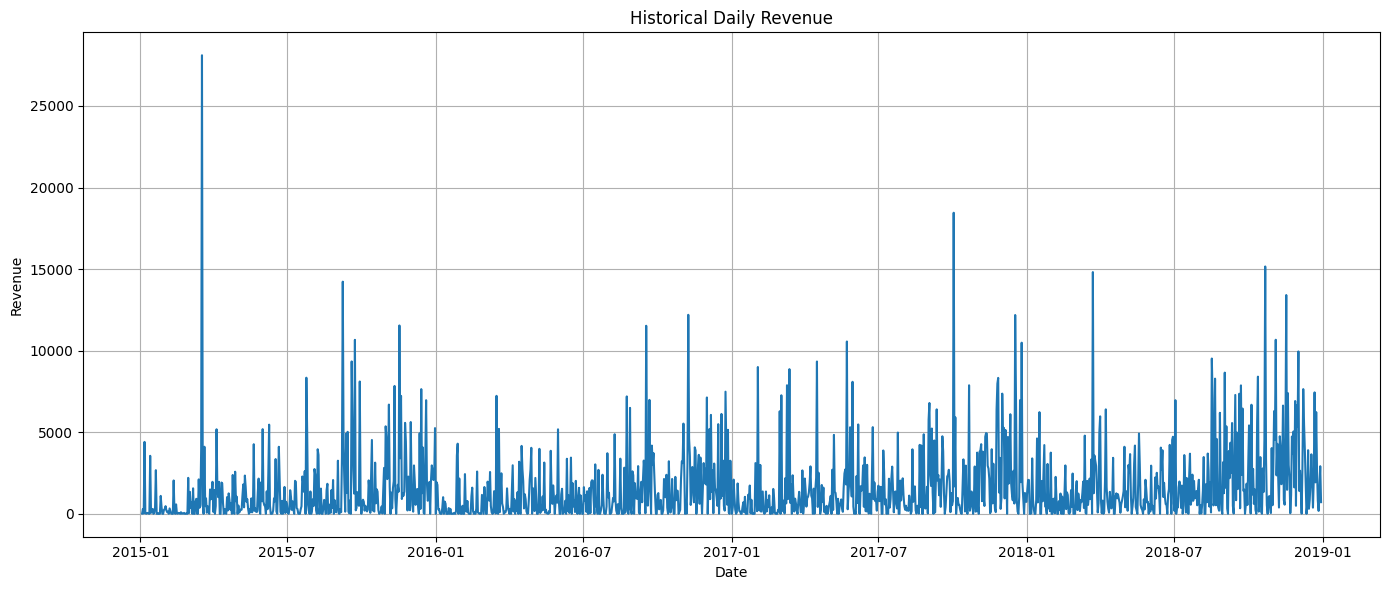

In [6]:
# Plot historical daily revenue

plt.figure(figsize=(14, 6))

plt.plot(
    daily_revenue.index,
    daily_revenue["Revenue"]
)

plt.title("Historical Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# Convert daily revenue into monthly revenue
monthly_revenue = revenue_data["Revenue"].resample("ME").sum()

print("Monthly Revenue:")
display(monthly_revenue.head(12))

Monthly Revenue:


Date
2015-01-31    14205.7070
2015-02-28     4519.8920
2015-03-31    55205.7970
2015-04-30    27906.8550
2015-05-31    23644.3030
2015-06-30    34322.9356
2015-07-31    33781.5430
2015-08-31    27117.5365
2015-09-30    81623.5268
2015-10-31    31453.3930
2015-11-30    77907.6607
2015-12-31    68167.0585
Freq: ME, Name: Revenue, dtype: float64

In [8]:
# Make a copy of the revenue data
revenue_data = daily_revenue.copy()

# Make sure Date is a datetime index
revenue_data.index = pd.to_datetime(revenue_data.index)

print(revenue_data.head())

             Revenue
Date                
2015-01-03    16.448
2015-01-04   288.060
2015-01-05    19.536
2015-01-06  4407.100
2015-01-07    87.158


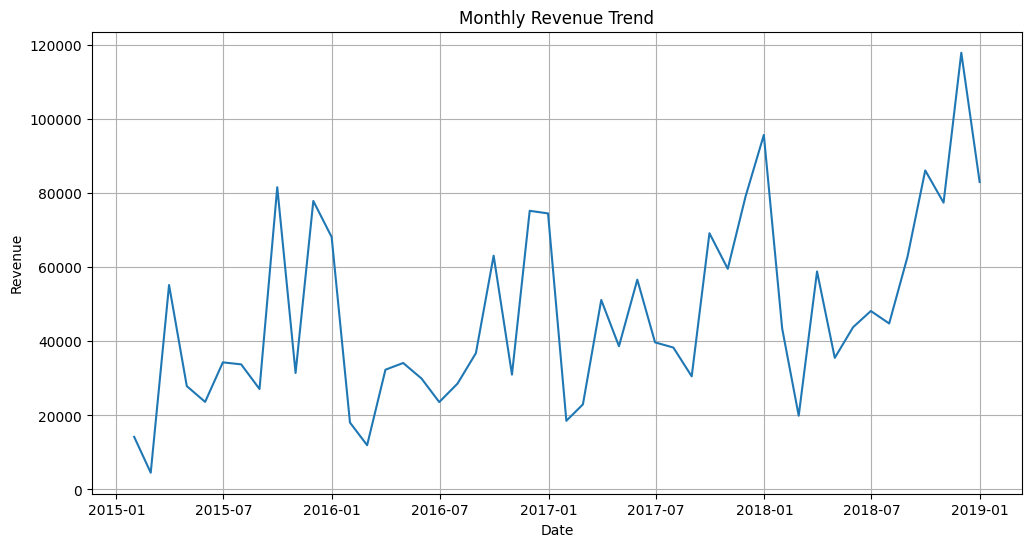

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

In [11]:
# Split monthly revenue into training and testing data

train_size = int(len(monthly_revenue) * 0.8)

train_revenue = monthly_revenue.iloc[:train_size]
test_revenue = monthly_revenue.iloc[train_size:]

print("Training records:", len(train_revenue))
print("Testing records:", len(test_revenue))

print("\nTraining period:")
print(train_revenue.index.min(), "to", train_revenue.index.max())

print("\nTesting period:")
print(test_revenue.index.min(), "to", test_revenue.index.max())

Training records: 38
Testing records: 10

Training period:
2015-01-31 00:00:00 to 2018-02-28 00:00:00

Testing period:
2018-03-31 00:00:00 to 2018-12-31 00:00:00


In [14]:
import statsmodels

print("Statsmodels version:", statsmodels.__version__)

Statsmodels version: 0.15.0


In [13]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\shrad\AppData\Local\Programs\Python\Python310\python.exe
3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [15]:
from statsmodels.tsa.arima.model import ARIMA

# Build ARIMA model
arima_model = ARIMA(
    train_revenue,
    order=(1, 1, 1)
)

# Train the model
arima_fitted = arima_model.fit()

print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                   38
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -424.929
Date:                Thu, 01 Oct 2026   AIC                            855.857
Time:                        21:00:07   BIC                            860.690
Sample:                    01-31-2015   HQIC                           857.561
                         - 02-28-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2319      0.316      0.735      0.462      -0.387       0.851
ma.L1         -0.9016      0.149     -6.035      0.000      -1.194      -0.609
sigma2      6.301e+08   8.44e-11   7.47e+18      0.0

In [16]:
# Forecast the 10-month testing period

arima_forecast = arima_fitted.forecast(
    steps=len(test_revenue)
)

# Keep the same dates as the test data
arima_forecast.index = test_revenue.index

print("ARIMA Forecast")
print("----------------")
display(arima_forecast)

ARIMA Forecast
----------------


Date
2018-03-31    41261.110809
2018-04-30    46210.673570
2018-05-31    47358.660511
2018-06-30    47624.921206
2018-07-31    47686.676923
2018-08-31    47701.000362
2018-09-30    47704.322498
2018-10-31    47705.093024
2018-11-30    47705.271738
2018-12-31    47705.313188
Freq: ME, Name: predicted_mean, dtype: float64

In [17]:
from sklearn.metrics import mean_absolute_error

arima_mae = mean_absolute_error(
    test_revenue,
    arima_forecast
)

print("ARIMA Forecast Performance")
print("--------------------------")
print("MAE:", round(arima_mae, 2))


ARIMA Forecast Performance
--------------------------
MAE: 22411.75


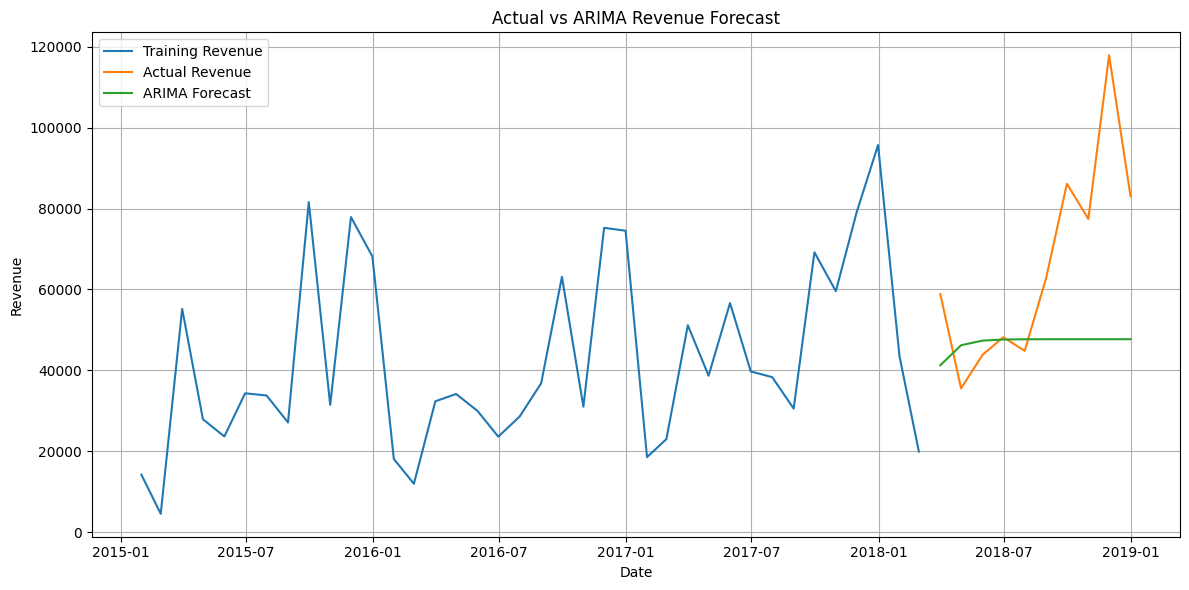

In [18]:
plt.figure(figsize=(12, 6))

# Historical training revenue
plt.plot(
    train_revenue.index,
    train_revenue.values,
    label="Training Revenue"
)

# Actual testing revenue
plt.plot(
    test_revenue.index,
    test_revenue.values,
    label="Actual Revenue"
)

# ARIMA predictions
plt.plot(
    arima_forecast.index,
    arima_forecast.values,
    label="ARIMA Forecast"
)

plt.title("Actual vs ARIMA Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_revenue,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fitted = sarima_model.fit(disp=False)

print(sarima_fitted.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            Revenue   No. Observations:                   38
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -118.582
Date:                            Thu, 01 Oct 2026   AIC                            247.163
Time:                                    21:02:48   BIC                            249.153
Sample:                                01-31-2015   HQIC                           245.909
                                     - 02-28-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2499      0.668     -0.374      0.708      -1.559       1.059
ma.L1         -0.9858      0.982   

c:\Users\shrad\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


In [21]:
# Fit the SARIMA model
sarima_results = sarima_model.fit(disp=False)

print("SARIMA model fitted successfully!")

SARIMA model fitted successfully!


c:\Users\shrad\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


In [23]:
# SARIMA forecast for the testing period

sarima_forecast = sarima_model.get_forecast(
    steps=len(test_data)
).predicted_mean

# Keep the same index as test data
sarima_forecast.index = test_data.index

print("SARIMA Forecast:")
display(sarima_forecast)

AttributeError: 'SARIMAX' object has no attribute 'get_forecast'

In [26]:
# Recreate training and testing data

train_data = monthly_revenue.iloc[:38]
test_data = monthly_revenue.iloc[38:]

print("Training records:", len(train_data))
print("Testing records:", len(test_data))

print("\nTraining period:")
print(train_data.index.min(), "to", train_data.index.max())

print("\nTesting period:")
print(test_data.index.min(), "to", test_data.index.max())

Training records: 38
Testing records: 10

Training period:
2015-01-31 00:00:00 to 2018-02-28 00:00:00

Testing period:
2018-03-31 00:00:00 to 2018-12-31 00:00:00


In [28]:
# Recreate training and testing data correctly

train_data = monthly_revenue.iloc[:38]
test_data = monthly_revenue.iloc[38:]

print("Training records:", len(train_data))
print("Testing records:", len(test_data))

print("\nTraining period:")
print(train_data.index.min(), "to", train_data.index.max())

print("\nTesting period:")
print(test_data.index.min(), "to", test_data.index.max())

Training records: 38
Testing records: 10

Training period:
2015-01-31 00:00:00 to 2018-02-28 00:00:00

Testing period:
2018-03-31 00:00:00 to 2018-12-31 00:00:00


In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# Build SARIMA model
sarima_model = SARIMAX(
    train_data,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fit the model
sarima_results = sarima_model.fit(disp=False)

# Forecast 10 testing months
sarima_forecast = sarima_results.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1
)

# Use actual testing dates
sarima_forecast.index = test_data.index

# Evaluate
sarima_mae = mean_absolute_error(
    test_data,
    sarima_forecast
)

print("SARIMA Forecast Performance")
print("---------------------------")
print("MAE:", round(sarima_mae, 2))

print("\nSARIMA Forecast:")
display(sarima_forecast)

c:\Users\shrad\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


SARIMA Forecast Performance
---------------------------
MAE: 13455.42

SARIMA Forecast:


Date
2018-03-31     65967.980544
2018-04-30     49975.622665
2018-05-31     67126.476872
2018-06-30     50965.585467
2018-07-31     50165.780072
2018-08-31     43691.568653
2018-09-30     81418.570170
2018-10-31     69700.948010
2018-11-30     91378.954325
2018-12-31    106443.341045
Freq: ME, Name: predicted_mean, dtype: float64

In [30]:
from sklearn.metrics import mean_absolute_error

sarima_mae = mean_absolute_error(
    test_data,
    sarima_forecast
)

print("SARIMA Forecast Performance")
print("---------------------------")
print("MAE:", round(sarima_mae, 2))

SARIMA Forecast Performance
---------------------------
MAE: 13455.42


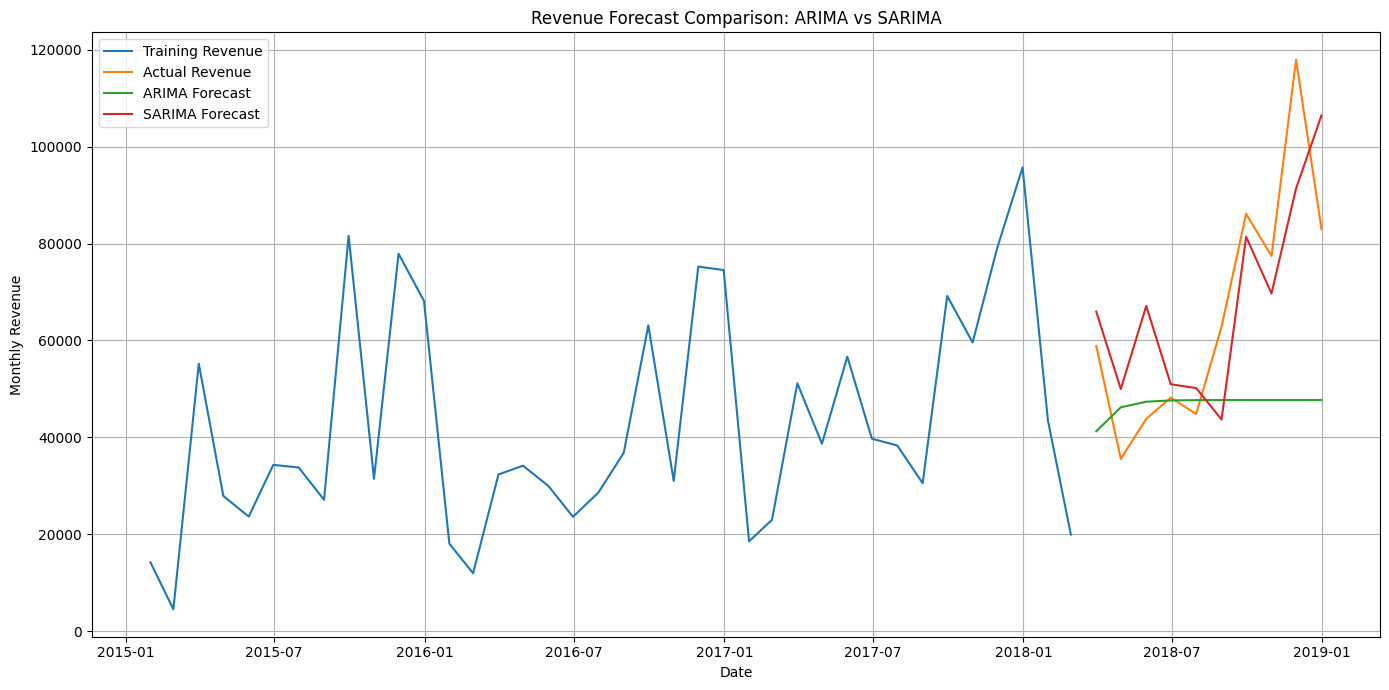

In [31]:
plt.figure(figsize=(14, 7))

# Historical training data
plt.plot(
    train_data.index,
    train_data.values,
    label="Training Revenue"
)

# Actual test revenue
plt.plot(
    test_data.index,
    test_data.values,
    label="Actual Revenue"
)

# ARIMA forecast
plt.plot(
    arima_forecast.index,
    arima_forecast.values,
    label="ARIMA Forecast"
)

# SARIMA forecast
plt.plot(
    sarima_forecast.index,
    sarima_forecast.values,
    label="SARIMA Forecast"
)

plt.title("Revenue Forecast Comparison: ARIMA vs SARIMA")
plt.xlabel("Date")
plt.ylabel("Monthly Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
plt.savefig("day37_revenue_forecast_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


<Figure size 640x480 with 0 Axes>

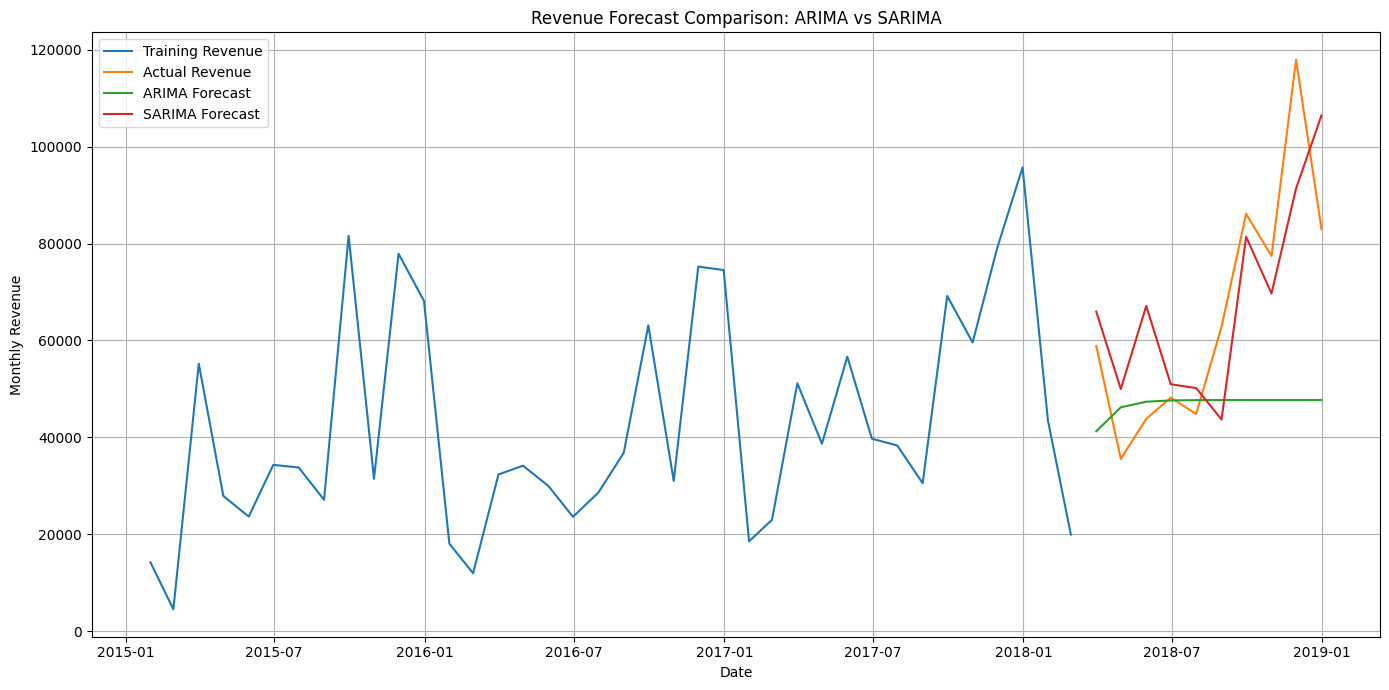

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Historical training revenue
plt.plot(
    train_data.index,
    train_data.values,
    label="Training Revenue"
)

# Actual test revenue
plt.plot(
    test_data.index,
    test_data.values,
    label="Actual Revenue"
)

# ARIMA forecast
plt.plot(
    arima_forecast.index,
    arima_forecast.values,
    label="ARIMA Forecast"
)

# SARIMA forecast
plt.plot(
    sarima_forecast.index,
    sarima_forecast.values,
    label="SARIMA Forecast"
)

plt.title("Revenue Forecast Comparison: ARIMA vs SARIMA")
plt.xlabel("Date")
plt.ylabel("Monthly Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()

# SAVE BEFORE SHOW
plt.savefig(
    "day37_revenue_forecast_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
# Compare ARIMA and SARIMA performance

comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "MAE": [arima_mae, sarima_mae]
})

print("Revenue Forecast Model Comparison")
print("----------------------------------")
display(comparison)

Revenue Forecast Model Comparison
----------------------------------


,Model,MAE
0,ARIMA,22411.753338
1,SARIMA,13455.424211
